**PROBLEM DESCRIPTION**

**Flooding is a recurring natural disaster in Karimganj (Sribhumi) District, Assam, India, particularly during the monsoon season. The district** **is ***traversed by major rivers such as the Kushiyara, Longai, and Singla, which frequently overflow due to prolonged heavy rainfall. These floods** **damagehomes, roads, schools, farmland, and public infrastructure, while also disrupting transportation and economic activities.**

**Current flood warning systems often rely on limited monitoring and may not provide sufficiently accurate or timely forecasts for local communities.** **As a result, emergency response and resource allocation become more difficult, increasing the risk to lives and property.**

**This project aims to develop an AI-powered flood prediction system that integrates historical flood records, rainfall data, river water levels, topographical information, and weather conditions to predict the probability of flooding. By providing early warnings and risk assessments, the system will help government agencies, disaster management authorities, and local communities prepare for flood events, reduce losses, and improve disaster response.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib 
import seaborn as sns
import sklearn
from sklearn.metrics import mutual_info_score
from sklearn.ensemble  import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction import DictVectorizer 
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

**DATA PREPARATION AND  EXPLORATOTY DATA ANALYSIS**

In [2]:
df = pd.read_csv('flood_data.csv')
df.head()

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,3,8,6,6,4,4,6,2,3,2,...,10,7,4,2,3,4,3,2,6,0.450
1,8,4,5,7,7,9,1,5,5,4,...,9,2,6,2,1,1,9,1,3,0.475
2,3,10,4,1,7,5,4,7,4,9,...,7,4,4,8,6,1,8,3,6,0.515
3,4,4,2,7,3,4,1,4,6,4,...,4,2,6,6,8,8,6,6,10,0.520
4,3,7,5,2,5,8,5,2,7,5,...,7,6,5,3,3,4,4,3,4,0.475


In [3]:
df.isnull().sum()

MonsoonIntensity                   0
TopographyDrainage                 0
RiverManagement                    0
Deforestation                      0
Urbanization                       0
ClimateChange                      0
DamsQuality                        0
Siltation                          0
AgriculturalPractices              0
Encroachments                      0
IneffectiveDisasterPreparedness    0
DrainageSystems                    0
CoastalVulnerability               0
Landslides                         0
Watersheds                         0
DeterioratingInfrastructure        0
PopulationScore                    0
WetlandLoss                        0
InadequatePlanning                 0
PoliticalFactors                   0
FloodProbability                   0
dtype: int64

In [4]:
df.columns

Index(['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement',
       'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality',
       'Siltation', 'AgriculturalPractices', 'Encroachments',
       'IneffectiveDisasterPreparedness', 'DrainageSystems',
       'CoastalVulnerability', 'Landslides', 'Watersheds',
       'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss',
       'InadequatePlanning', 'PoliticalFactors', 'FloodProbability'],
      dtype='str')

In [5]:
df['FloodProbability'].unique()

array([0.45 , 0.475, 0.515, 0.52 , 0.47 , 0.57 , 0.585, 0.58 , 0.555,
       0.455, 0.525, 0.48 , 0.44 , 0.465, 0.53 , 0.485, 0.55 , 0.605,
       0.495, 0.445, 0.545, 0.575, 0.43 , 0.565, 0.56 , 0.505, 0.635,
       0.425, 0.595, 0.46 , 0.61 , 0.5  , 0.42 , 0.51 , 0.54 , 0.355,
       0.62 , 0.415, 0.59 , 0.6  , 0.49 , 0.615, 0.535, 0.435, 0.405,
       0.41 , 0.38 , 0.385, 0.4  , 0.395, 0.675, 0.39 , 0.625, 0.34 ,
       0.37 , 0.63 , 0.365, 0.66 , 0.68 , 0.36 , 0.64 , 0.375, 0.665,
       0.345, 0.65 , 0.35 , 0.645, 0.67 , 0.655, 0.32 , 0.71 , 0.69 ,
       0.705, 0.335, 0.7  , 0.315, 0.325, 0.685, 0.695, 0.715, 0.33 ,
       0.285, 0.725])

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   MonsoonIntensity                 50000 non-null  int64  
 1   TopographyDrainage               50000 non-null  int64  
 2   RiverManagement                  50000 non-null  int64  
 3   Deforestation                    50000 non-null  int64  
 4   Urbanization                     50000 non-null  int64  
 5   ClimateChange                    50000 non-null  int64  
 6   DamsQuality                      50000 non-null  int64  
 7   Siltation                        50000 non-null  int64  
 8   AgriculturalPractices            50000 non-null  int64  
 9   Encroachments                    50000 non-null  int64  
 10  IneffectiveDisasterPreparedness  50000 non-null  int64  
 11  DrainageSystems                  50000 non-null  int64  
 12  CoastalVulnerability         

In [7]:
df.describe().round(2)


,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
count,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,...,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,4.99,4.98,5.02,5.01,4.99,4.99,5.02,4.99,5.01,5.01,...,5.01,5.00,4.98,4.98,4.99,4.98,5.01,4.99,4.99,0.50
std,2.24,2.25,2.23,2.22,2.24,2.23,2.24,2.23,2.23,2.24,...,2.24,2.25,2.23,2.23,2.23,2.24,2.23,2.23,2.25,0.05
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.28
25%,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,...,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,0.46
50%,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,...,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,0.50
75%,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,...,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,0.54
max,16.00,18.00,16.00,17.00,17.00,17.00,16.00,16.00,16.00,18.00,...,17.00,17.00,16.00,16.00,17.00,19.00,22.00,16.00,16.00,0.72


In [8]:
numerical = list(df.dtypes[(df.dtypes=='int64') | (df.dtypes=='float64')].index)
numerical

['MonsoonIntensity',
 'TopographyDrainage',
 'RiverManagement',
 'Deforestation',
 'Urbanization',
 'ClimateChange',
 'DamsQuality',
 'Siltation',
 'AgriculturalPractices',
 'Encroachments',
 'IneffectiveDisasterPreparedness',
 'DrainageSystems',
 'CoastalVulnerability',
 'Landslides',
 'Watersheds',
 'DeterioratingInfrastructure',
 'PopulationScore',
 'WetlandLoss',
 'InadequatePlanning',
 'PoliticalFactors',
 'FloodProbability']

**VISUALIZATION OF PATTERNS**

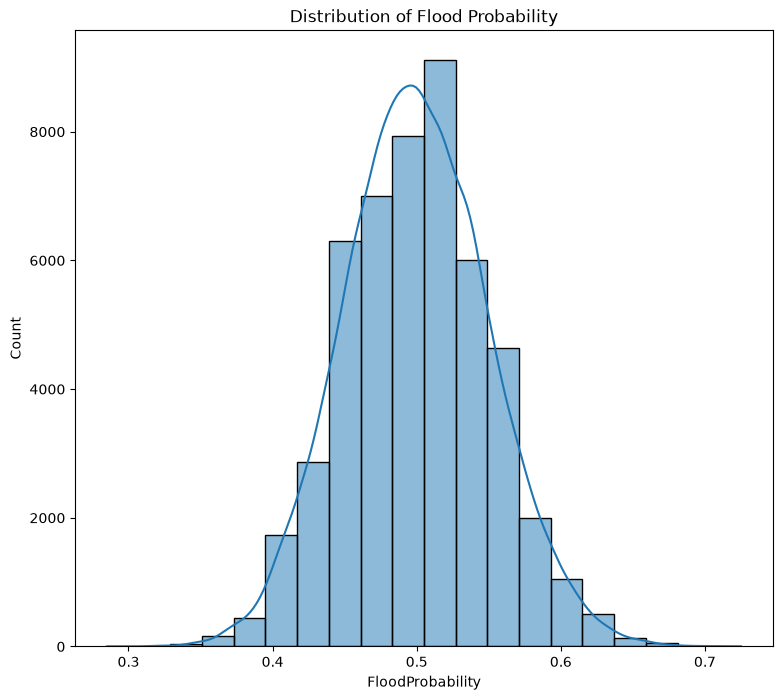

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9,8))
sns.histplot(df['FloodProbability'], bins=20, kde=True)
plt.title('Distribution of Flood Probability')
plt.show()

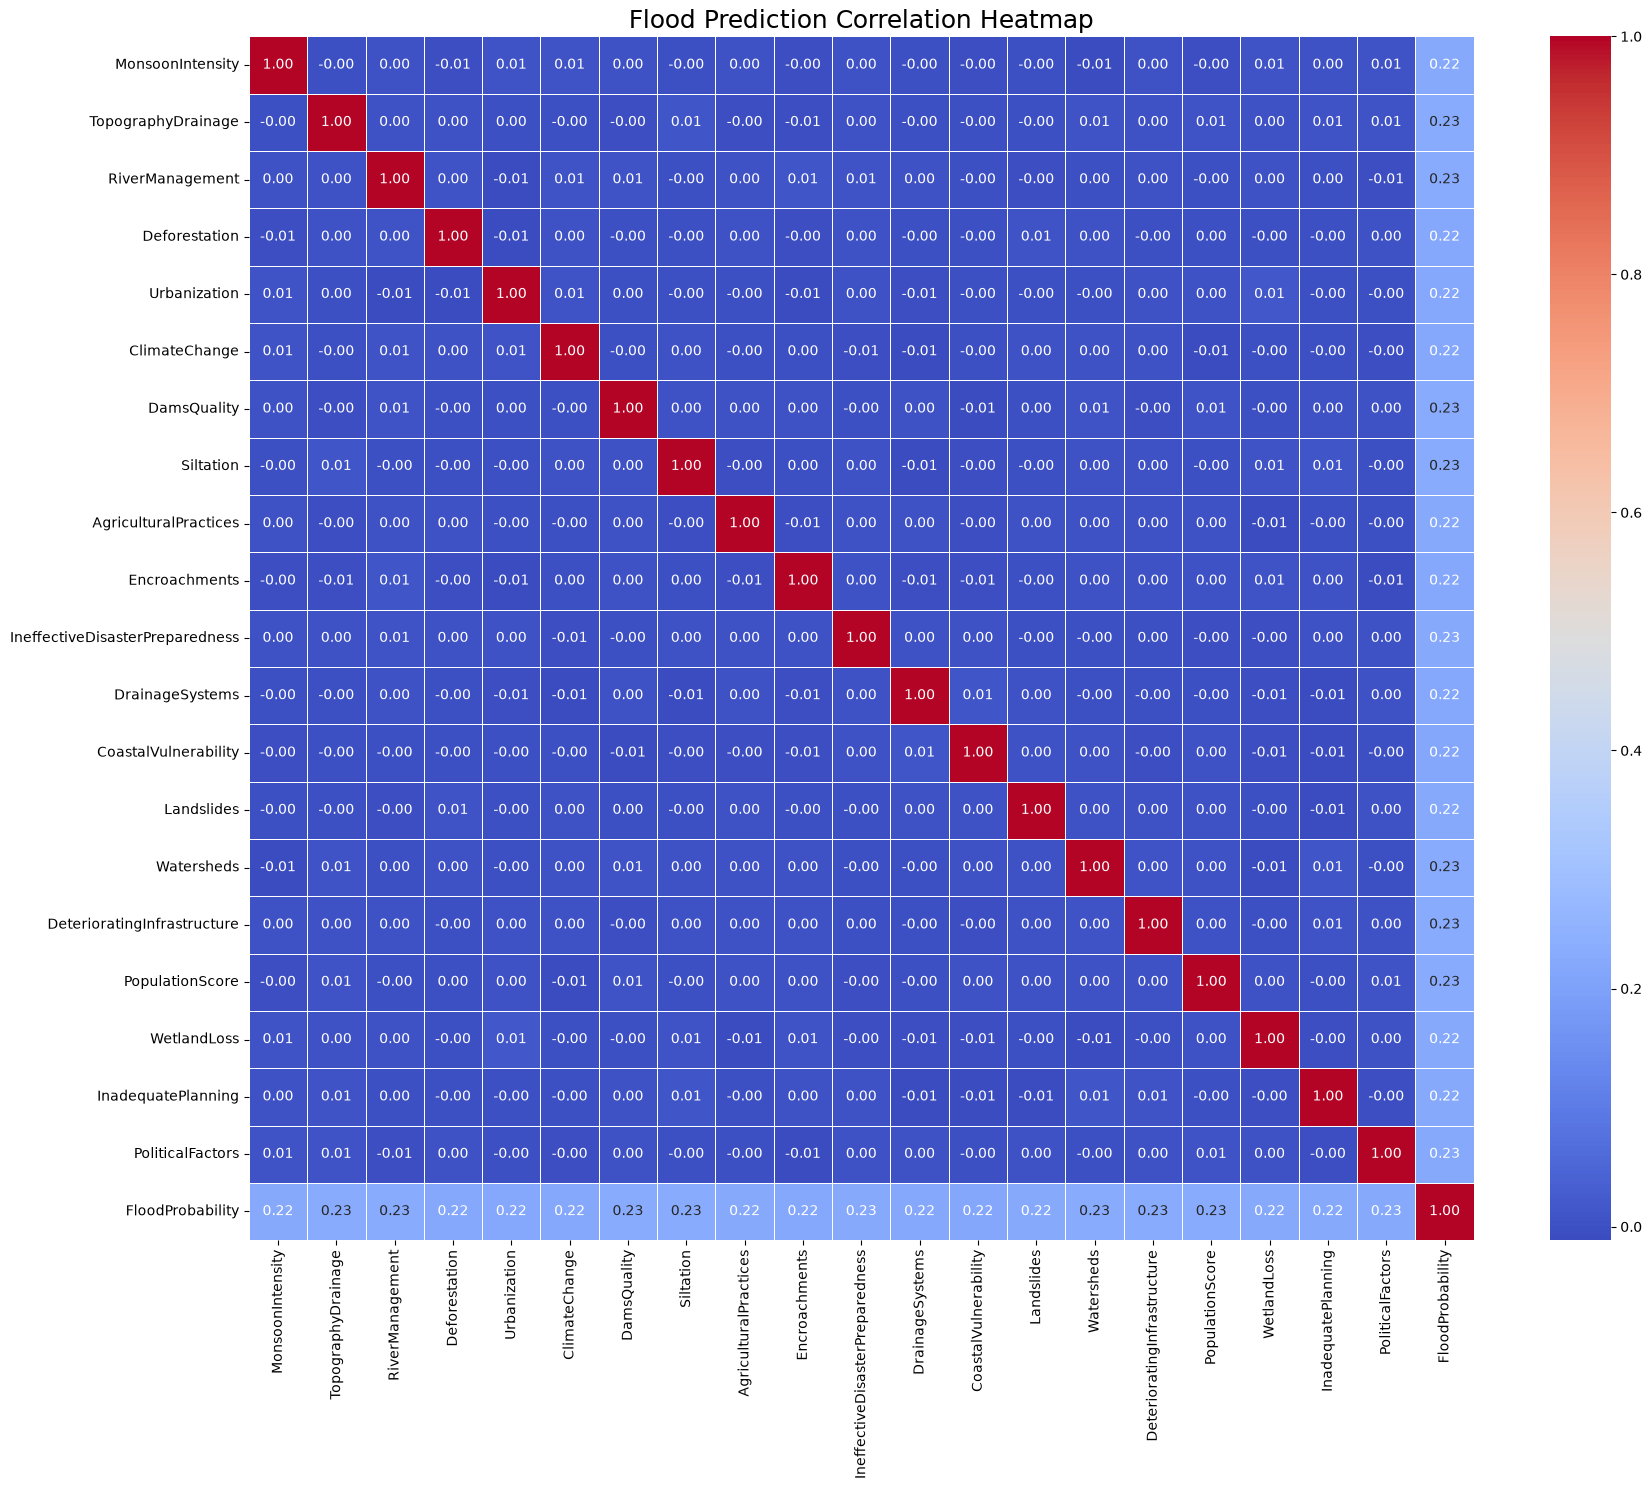

In [10]:
plt.figure(figsize=(18, 15))

sns.heatmap(
    df[numerical].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Flood Prediction Correlation Heatmap", fontsize=18)
plt.tight_layout()
plt.show()


array([[<Axes: title={'center': 'MonsoonIntensity'}>,
        <Axes: title={'center': 'TopographyDrainage'}>,
        <Axes: title={'center': 'RiverManagement'}>,
        <Axes: title={'center': 'Deforestation'}>,
        <Axes: title={'center': 'Urbanization'}>],
       [<Axes: title={'center': 'ClimateChange'}>,
        <Axes: title={'center': 'DamsQuality'}>,
        <Axes: title={'center': 'Siltation'}>,
        <Axes: title={'center': 'AgriculturalPractices'}>,
        <Axes: title={'center': 'Encroachments'}>],
       [<Axes: title={'center': 'IneffectiveDisasterPreparedness'}>,
        <Axes: title={'center': 'DrainageSystems'}>,
        <Axes: title={'center': 'CoastalVulnerability'}>,
        <Axes: title={'center': 'Landslides'}>,
        <Axes: title={'center': 'Watersheds'}>],
       [<Axes: title={'center': 'DeterioratingInfrastructure'}>,
        <Axes: title={'center': 'PopulationScore'}>,
        <Axes: title={'center': 'WetlandLoss'}>,
        <Axes: title={'center': '

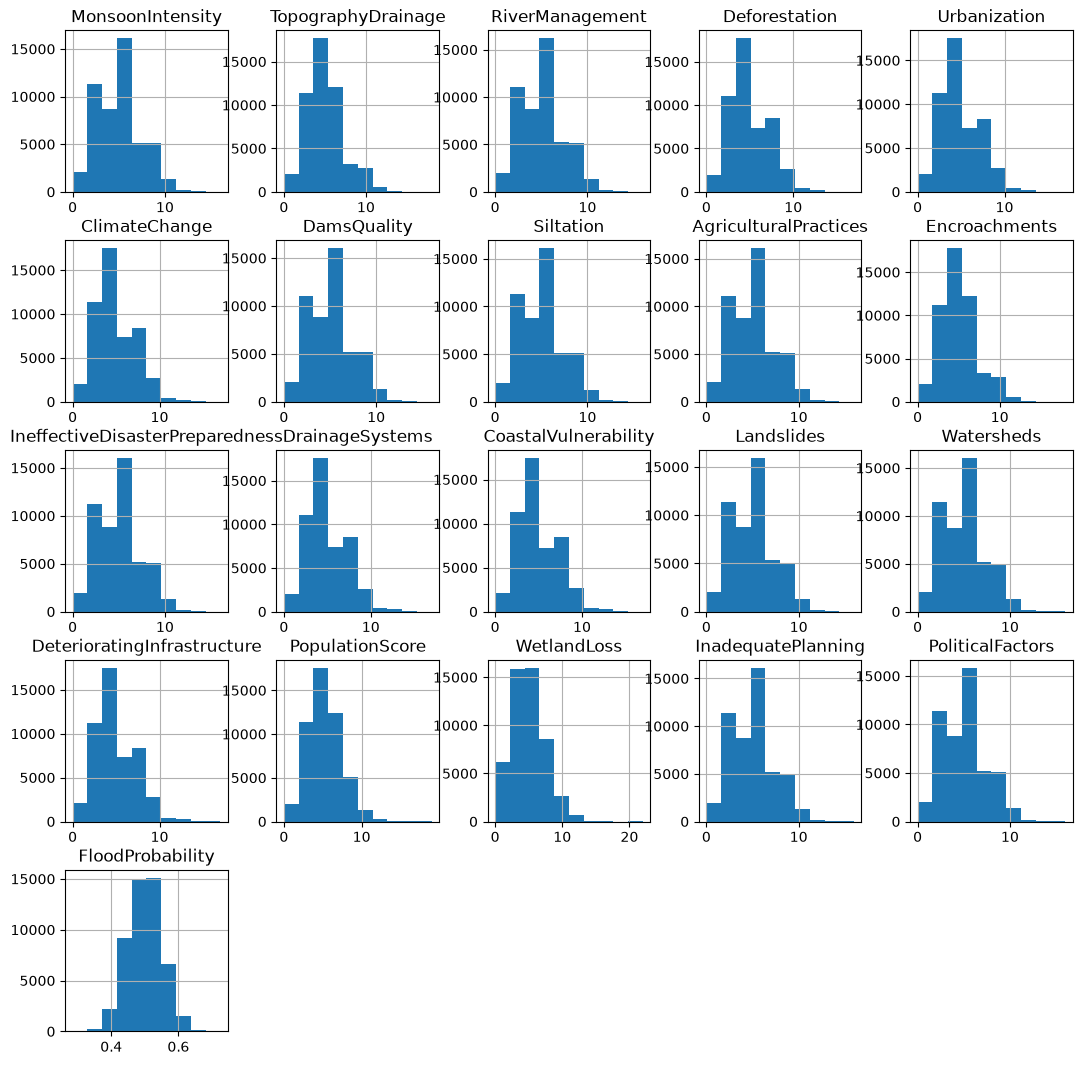

In [11]:
df[numerical].hist(figsize = (13, 13))

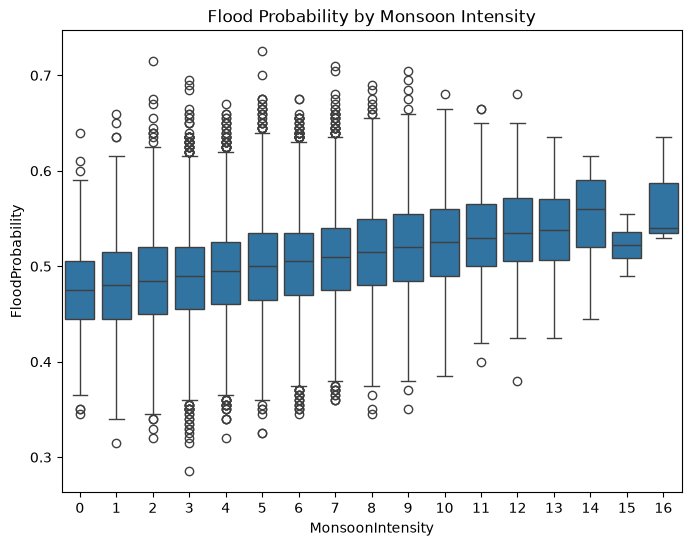

In [12]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    x="MonsoonIntensity",
    y="FloodProbability",
    data=df
)

plt.title("Flood Probability by Monsoon Intensity")
plt.show()

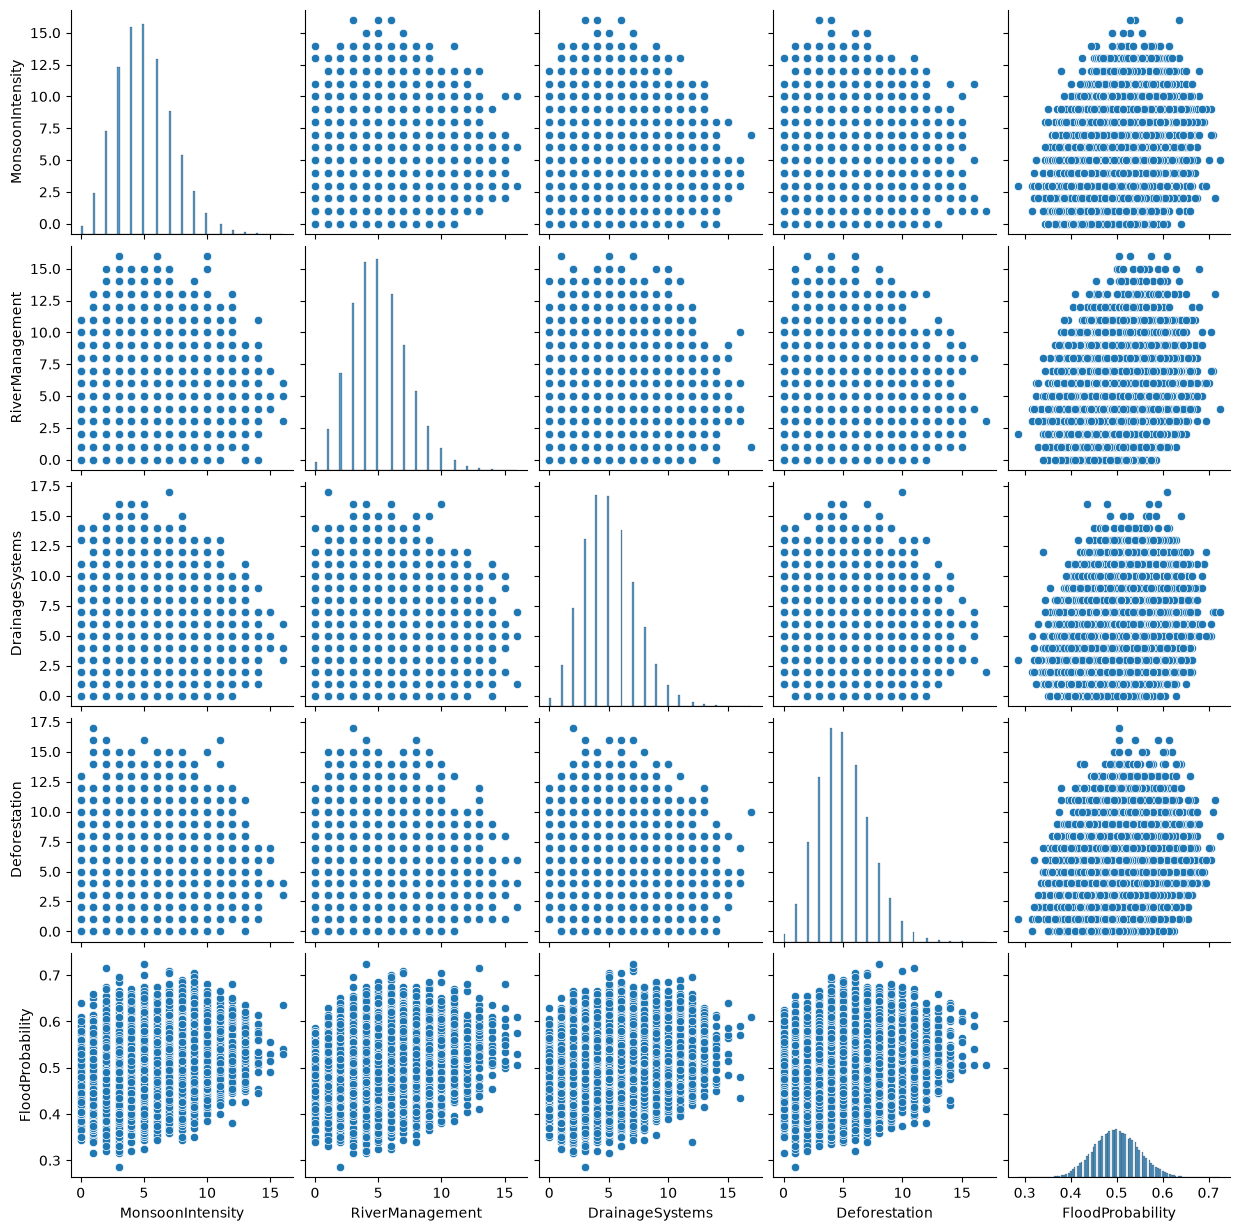

In [13]:
cols = [
    "MonsoonIntensity",
    "RiverManagement",
    "DrainageSystems",
    "Deforestation",
    "FloodProbability"
]

sns.pairplot(df[cols], diag_kind="hist")
plt.show()

**SPLITTING THE DATA INTO VALIDATION /TRAIN/ TEST_SPLIT**

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42)


In [16]:
len(df_train), len(df_val), len(df_test)

(30000, 10000, 10000)

In [17]:
df_train.reset_index(drop=True)
df_val.reset_index(drop=True)
df_test.reset_index(drop=True)

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,7,3,4,4,5,6,2,5,5,4,...,6,4,6,5,4,2,5,5,3,0.455
1,4,7,7,3,5,7,5,2,7,6,...,3,5,5,9,2,10,3,2,4,0.495
2,2,3,3,4,5,4,7,7,2,3,...,8,7,5,5,2,4,5,7,3,0.470
3,5,4,5,7,8,2,5,5,5,8,...,6,2,3,4,5,5,2,3,4,0.460
4,3,9,5,3,3,4,6,9,0,5,...,5,7,2,6,5,8,3,5,3,0.465
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,3,4,4,3,5,4,5,4,5,6,...,7,6,4,5,3,9,1,5,8,0.475
9996,7,2,7,6,1,2,4,4,4,8,...,5,7,5,3,6,4,8,10,6,0.520
9997,7,3,4,3,6,4,6,3,4,8,...,2,6,5,10,6,6,5,5,5,0.505
9998,5,3,4,5,6,13,6,3,12,7,...,6,3,9,1,6,11,5,9,6,0.620


In [18]:
X_train = df_train.drop("FloodProbability", axis=1)
X_val = df_val.drop("FloodProbability", axis=1)
X_test = df_test.drop("FloodProbability", axis=1)


In [19]:
y_train = df_train.FloodProbability.values
y_val = df_val.FloodProbability.values
y_test = df_test.FloodProbability.values

**PERFOMING ONE HOT ENCODING**

In [20]:
train_dicts = df_train.to_dict(orient = 'records')
dv= DictVectorizer(sparse = False) 
X_train = dv.fit_transform(train_dicts)

In [21]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [22]:
val_dicts = df_val.to_dict(orient = 'records')
X_val = dv.transform(val_dicts)

In [23]:
test_dicts = df_test.to_dict(orient = 'records')
X_test = dv.transform(test_dicts)

**TRAINING SEVERAL MODELS THEN FINE TUNING**

RANDOM FOREST REGRESSOR

In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd

scores = []

for d in [5, 10, 15]:
    for n in range(10, 201, 10):

        rf = RandomForestRegressor(
            n_estimators=n,
            max_depth=d,
            random_state=42
        )

        rf.fit(X_train, y_train)

        y_pred = rf.predict(X_val)

        r2 = r2_score(y_val, y_pred)
        rmse = mean_squared_error(y_val, y_pred) ** 0.5

        scores.append((d, n, r2, rmse))

df_scores = pd.DataFrame(
    scores,
    columns=["max_depth", "n_estimators", "R2", "RMSE"]
)

df_scores.head()

,max_depth,n_estimators,R2,RMSE
0,5,10,0.998313,0.002042
1,5,20,0.998307,0.002045
2,5,30,0.998304,0.002047
3,5,40,0.998302,0.002048
4,5,50,0.998308,0.002045


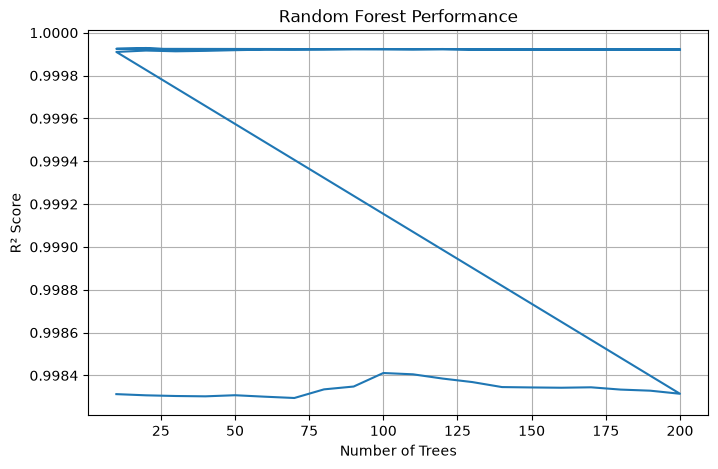

In [25]:
plt.figure(figsize=(8,5))

plt.plot(df_scores["n_estimators"], df_scores["R2"])

plt.xlabel("Number of Trees")
plt.ylabel("R² Score")
plt.title("Random Forest Performance")

plt.grid(True)

plt.show()

In [26]:
scores = []

for depth in [5, 10, 15, 20, None]:
    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=depth,
        random_state=42
    )

    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_val)

    r2 = r2_score(y_val, y_pred)

    scores.append((depth, r2))

pd.DataFrame(scores, columns=["max_depth", "R2"])

,max_depth,R2
0,5.0,0.998411
1,10.0,0.999924
2,15.0,0.999923
3,20.0,0.999923
4,NaN,0.999921


In [27]:
df_scores.columns

Index(['max_depth', 'n_estimators', 'R2', 'RMSE'], dtype='str')

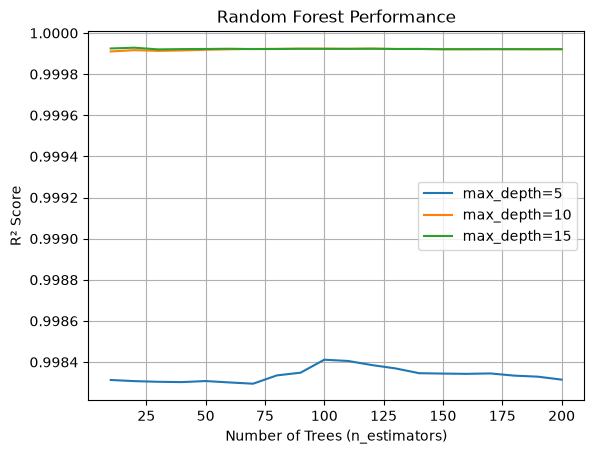

In [28]:
for d in [5, 10, 15]:
    df_subset = df_scores[df_scores["max_depth"] == d]

    plt.plot(
        df_subset["n_estimators"],
        df_subset["R2"], 
            label=f"max_depth={d}"
    )

plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("R² Score")
plt.title("Random Forest Performance")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
max_depth = 15

In [30]:
scores = []

for s in [1, 3, 5, 10, 50]:
    for n in range(10, 201, 10):

        rf = RandomForestRegressor(
            n_estimators=n,
            max_depth=15, 
            min_samples_leaf=s,
            random_state=1
        )

        rf.fit(X_train, y_train)

        y_pred = rf.predict(X_val)

        r2 = r2_score(y_val, y_pred)

        scores.append((s, n, r2))

columns = ['min_samples_leaf', 'n_estimators', 'R2']
df_scores = pd.DataFrame(scores, columns=columns)

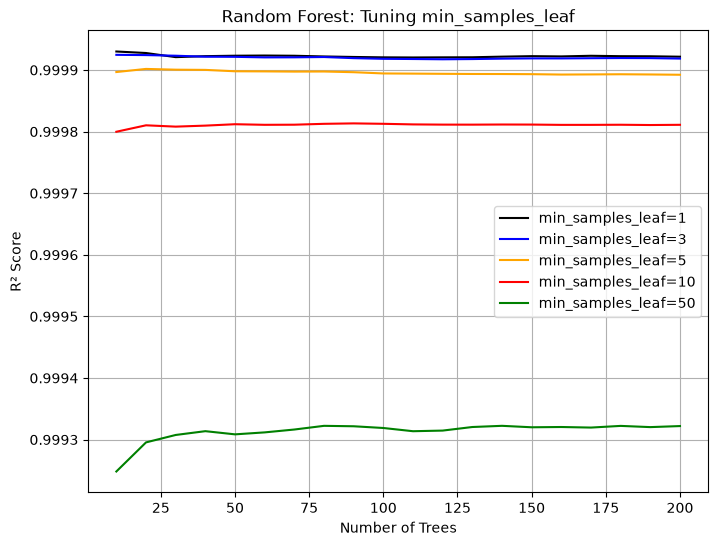

In [31]:
colors = ['black', 'blue', 'orange', 'red', 'green']
values = [1, 3, 5, 10, 50]

plt.figure(figsize=(8,6))

for s, col in zip(values, colors):
    df_subset = df_scores[df_scores.min_samples_leaf == s]

    plt.plot(
        df_subset.n_estimators,
        df_subset.R2,
        color=col,
        label=f"min_samples_leaf={s}"
    )

plt.xlabel("Number of Trees")
plt.ylabel("R² Score")
plt.title("Random Forest: Tuning min_samples_leaf")
plt.legend()
plt.grid(True)
plt.show()

In [32]:
min_samples_leaf = 1

In [33]:
max_depth = 15
min_samples_leaf = 1

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=max_depth,
    min_samples_leaf=min_samples_leaf,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of 

XG BOOST REGRESSOR

In [34]:
import xgboost as xgb
print(xgb.__version__)
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)

watchlist = [(dtrain, "train"), (dval, "eval")]


3.3.0


In [35]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.3,
    max_depth=6,
    min_child_weight=1,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_val)

print("R²:", r2_score(y_val, y_pred))
print("MAE:", mean_absolute_error(y_val, y_pred))
print("RMSE:", mean_squared_error(y_val, y_pred) ** 0.5)

R²: 0.9999506697021371
MAE: 1.2894937515260967e-05
RMSE: 0.00034908439295457583


DECISION TREE REGRESSOR

In [36]:
depths = [1, 2, 3, 4, 5, 6, 10, 15, 20, None]

for depth in depths:
    dt = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    dt.fit(X_train, y_train)

    y_pred = dt.predict(X_val)

    r2 = r2_score(y_val, y_pred)
    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))

    print(f"Depth={depth}, R²={r2:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}")

Depth=1, R²=0.6411, MAE=0.0238, RMSE=0.0298
Depth=2, R²=0.8825, MAE=0.0137, RMSE=0.0170
Depth=3, R²=0.9651, MAE=0.0073, RMSE=0.0093
Depth=4, R²=0.9904, MAE=0.0037, RMSE=0.0049
Depth=5, R²=0.9975, MAE=0.0014, RMSE=0.0025
Depth=6, R²=0.9996, MAE=0.0002, RMSE=0.0010
Depth=10, R²=0.9999, MAE=0.0000, RMSE=0.0005
Depth=15, R²=0.9999, MAE=0.0000, RMSE=0.0004
Depth=20, R²=0.9999, MAE=0.0000, RMSE=0.0004
Depth=None, R²=0.9999, MAE=0.0000, RMSE=0.0004


In [37]:
results = []

for d in [4, 5, 6]:
    for leaf in [1, 2, 5, 10, 20, 50]:
        dt = DecisionTreeRegressor(
            max_depth=d,
            min_samples_leaf=leaf,
            random_state=42
        )

        dt.fit(X_train, y_train)
        y_pred = dt.predict(X_val)

        results.append({
            "max_depth": d,
            "min_samples_leaf": leaf,
            "R²": r2_score(y_val, y_pred),
            "MAE": mean_absolute_error(y_val, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_val, y_pred))
        })

results = pd.DataFrame(results)
print(results)

    max_depth  min_samples_leaf        R²       MAE      RMSE
0           4                 1  0.990386  0.003701  0.004873
1           4                 2  0.990386  0.003701  0.004873
2           4                 5  0.990386  0.003701  0.004873
3           4                10  0.990386  0.003701  0.004873
4           4                20  0.990386  0.003701  0.004873
5           4                50  0.990386  0.003701  0.004873
6           5                 1  0.997548  0.001444  0.002461
7           5                 2  0.997548  0.001444  0.002461
8           5                 5  0.997548  0.001444  0.002461
9           5                10  0.997548  0.001444  0.002461
10          5                20  0.997548  0.001444  0.002461
11          5                50  0.997548  0.001444  0.002461
12          6                 1  0.999556  0.000165  0.001047
13          6                 2  0.999556  0.000165  0.001047
14          6                 5  0.999556  0.000165  0.001047
15      

In [38]:
df_scores_pivot = results.pivot(
    index="min_samples_leaf",
    columns="max_depth",
    values="RMSE" 
)

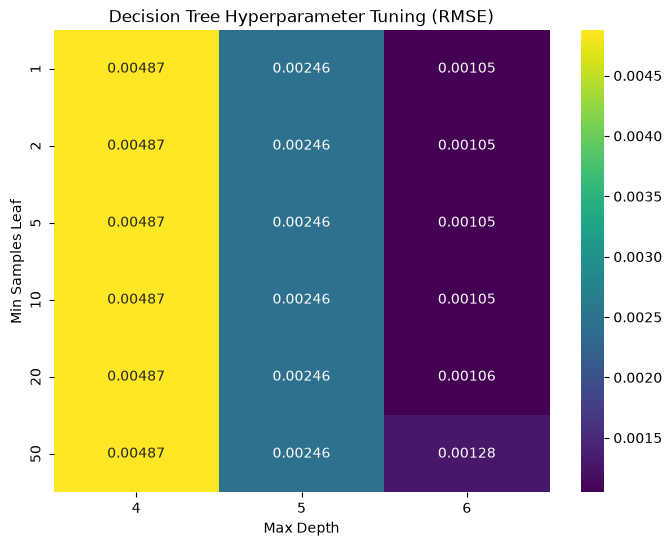

In [39]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_scores_pivot, annot=True, fmt=".5f", cmap="viridis")
plt.title("Decision Tree Hyperparameter Tuning (RMSE)")
plt.xlabel("Max Depth")
plt.ylabel("Min Samples Leaf")
plt.show()

CHOOSING THE BEST MODEL

We will pick xg boost regressor   because it has a coefficient of determination of  0.999951

SAVING THE MODEL

In [40]:
import pickle

In [41]:
output_file = "flood_prediction_model.bin"
output_file

'flood_prediction_model.bin'

In [42]:
with open(output_file, "wb") as f_out:
    pickle.dump(xgb_model, f_out)

print("Model saved successfully!")

Model saved successfully!


In [43]:
import pickle

with open("flood_prediction_model.bin", "rb") as f_in:
    xgb_model = pickle.load(f_in)

print(xgb_model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.3, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=1, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)


In [44]:
df

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,3,8,6,6,4,4,6,2,3,2,...,10,7,4,2,3,4,3,2,6,0.450
1,8,4,5,7,7,9,1,5,5,4,...,9,2,6,2,1,1,9,1,3,0.475
2,3,10,4,1,7,5,4,7,4,9,...,7,4,4,8,6,1,8,3,6,0.515
3,4,4,2,7,3,4,1,4,6,4,...,4,2,6,6,8,8,6,6,10,0.520
4,3,7,5,2,5,8,5,2,7,5,...,7,6,5,3,3,4,4,3,4,0.475
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,3,7,4,7,5,9,4,6,10,4,...,7,3,8,8,6,1,5,4,2,0.535
49996,3,10,3,8,3,3,4,4,3,11,...,8,6,3,6,4,4,2,4,5,0.510
49997,4,4,5,7,2,1,4,5,6,7,...,4,6,4,1,5,1,6,4,3,0.430
49998,4,5,4,4,6,3,10,2,6,11,...,6,3,4,7,6,2,4,0,11,0.515


In [45]:
import pickle

output_file = "flood_prediction_model.bin"
with open(output_file, "wb") as f_out:
    pickle.dump((dv, xgb_model), f_out, protocol=pickle.HIGHEST_PROTOCOL)

with open(output_file, "rb") as f_in:
    dv, model = pickle.load(f_in)

print(type(model), model.__class__.__module__, model.__class__.__name__)

# SAMPLE INPUT (use real values)
flood_data = {
    "MonsoonIntensity": 6,
    "TopographyDrainage": 7,
    "RiverManagement": 5,
    "Deforestation": 6,
    "Urbanization": 7,
    "ClimateChange": 8,
    "DamsQuality": 6,
    "Siltation": 7,
    "AgriculturalPractices": 5,
    "Encroachments": 6,
    "IneffectiveDisasterPreparedness": 5,
    "DrainageSystems": 4,
    "CoastalVulnerability": 3,
    "Landslides": 2,
    "Watersheds": 6,
    "DeterioratingInfrastructure": 5,
    "PopulationScore": 7,
    "WetlandLoss": 6,
    "InadequatePlanning": 7,
    "PoliticalFactors": 4,
}

X_new = dv.transform([flood_data])
predicted_probability = model.predict(X_new)[0]
print(f"Predicted Flood Probability: {predicted_probability:.3f}")

def print_risk_and_measure(p):
    if p >= 0.75:
        print("🚨 Very High Flood Risk")
        print("Measure: Evacuate to higher ground immediately and follow official orders.")
    elif p >= 0.50:
        print("⚠️ High Flood Risk")
        print("Measure: Prepare to evacuate — move valuables higher and charge devices.")
    elif p >= 0.25:
        print("🟡 Moderate Flood Risk")
        print("Measure: Monitor updates closely and have your emergency kit ready.")
    else:
        print("🟢 Low Flood Risk")
        print("Measure: Stay informed and review your household emergency plan.")

print_risk_and_measure(predicted_probability)

<class 'xgboost.sklearn.XGBRegressor'> xgboost.sklearn XGBRegressor
Predicted Flood Probability: 0.317
🟡 Moderate Flood Risk
Measure: Monitor updates closely and have your emergency kit ready.
